In [1]:
import sys
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models')

import torch
torch.use_deterministic_algorithms(True)
from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. cannot import name 'DMPNN' from 'deepchem.models.torch_models' (/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


In [2]:
X1 = pd.read_csv("mod_data/X1.1", index_col="QSPRID")
X2 = pd.read_csv("mod_data/X2.1", index_col="QSPRID")
X3 = pd.read_csv("mod_data/X3.1", index_col="QSPRID")
y1 = pd.read_csv("mod_data/y1.1", index_col="QSPRID")
y2 = pd.read_csv("mod_data/y2.1", index_col="QSPRID")
y3 = pd.read_csv("mod_data/y3.1", index_col="QSPRID")


In [3]:
X1

,300,301,302,303,304,305,306,307,308,309,...,RDkit_fr_piperdine,RDkit_fr_piperzine,RDkit_fr_pyridine,RDkit_fr_sulfide,RDkit_fr_sulfonamd,RDkit_fr_sulfone,RDkit_fr_thiazole,RDkit_fr_thiophene,RDkit_fr_unbrch_alkane,RDkit_qed
QSPRID,,,,,,,,,,,,,,,,,,,,,
A2ARDataset_000,-0.442472,0.207853,0.391181,0.222411,-0.084914,-0.652523,0.186761,-0.141471,-0.138574,0.327026,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.690353
A2ARDataset_001,-0.547015,0.326527,-0.055402,0.498394,0.059913,-0.783032,0.457208,-0.362948,0.182183,0.154815,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.488490
A2ARDataset_002,-0.183866,0.578967,0.161637,0.422820,-0.359473,-1.000239,0.778588,0.269597,0.671282,0.095040,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.389416
A2ARDataset_003,-0.255575,0.203898,0.418056,0.378673,-0.129638,-0.148893,0.742217,-0.251707,-0.097038,0.531059,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.441687
A2ARDataset_004,-0.687007,0.620376,0.137707,-0.190699,0.417505,-0.457825,0.332847,-0.721059,-0.052884,-0.030075,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.804595
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2ARDataset_483,-0.108826,1.003503,0.156762,-0.109018,-0.087699,-0.874875,0.539532,0.541044,0.533539,0.117385,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.339048
A2ARDataset_484,-0.223748,0.351416,-0.098620,0.191478,0.223344,-0.828098,0.288138,-0.034601,0.138777,0.187323,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.451445
A2ARDataset_485,0.170707,0.057631,0.364865,0.143474,0.144775,0.001812,0.526527,-0.131677,0.087674,0.613961,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.743722


In [4]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [5]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=1, random_state=42)
X1, y1 = smote.fit_resample(X1, y1)
display(pd.DataFrame(X1))

,0,1,2,3,4,5,6,7,8,9,...,2390,2391,2392,2393,2394,2395,2396,2397,2398,2399
0,-0.296463,-1.014346,0.704087,0.197034,-0.199916,0.056990,-1.262282,-0.085669,-1.053805,0.296247,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,0.856668
1,-0.670941,-0.525577,-1.236676,1.502286,0.377970,-0.372174,-0.045401,-0.789457,0.021136,-0.509625,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.299228
2,0.629879,0.514115,-0.293469,1.144865,-1.295461,-1.086432,1.400654,1.220583,1.660234,-0.789349,...,-0.290593,6.044705,1.105679,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.866536
3,0.373012,-1.030634,0.820882,0.936072,-0.378374,1.713116,1.237002,-0.435967,-0.914606,1.251034,...,-0.290593,-0.165434,1.105679,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.567226
4,-1.172401,0.684663,-0.397464,-1.756755,1.804830,0.697231,-0.604966,-1.927427,-0.766635,-1.374831,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,1.510832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789,-1.193043,-0.487364,-0.908142,1.116066,-0.271553,-0.376130,-0.633163,0.123939,1.031423,0.226711,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.918624
790,1.125096,1.186714,-0.128442,-0.240725,-1.569522,-0.687927,1.238028,0.160632,-1.380454,0.755241,...,-0.290593,-0.165434,0.291367,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,0.891481
791,-0.823325,-0.610447,-0.668821,1.034534,-0.353845,-0.572354,-0.119446,0.004899,1.136635,0.244145,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.984171
792,-0.336960,-1.640396,-0.558868,0.358328,-0.148476,0.579681,-1.060386,0.396513,-0.133678,0.005032,...,-0.290593,-0.165434,0.437196,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.059823


In [6]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit_transform(X1)
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1

In [7]:
from sklearn.decomposition import PCA
pca = PCA(n_components=n_components)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

In [8]:
n_components

323

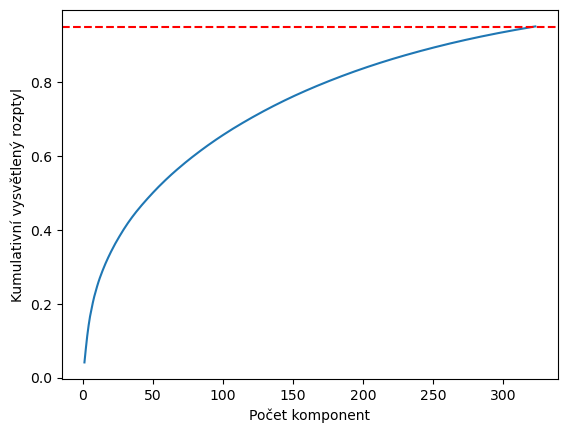

In [9]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [10]:
import importlib
# This part of your code directly loads MLP.py
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py'
module_name_for_direct_load = 'my_local_MLP_module' # Can be any unique name
spec = importlib.util.spec_from_file_location(module_name_for_direct_load, module_path)
if spec and spec.loader:
    neural_network = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(neural_network)
    MultiLayerPerceptron = neural_network.MultiLayerPerceptron
    print(f"Successfully loaded MLP directly from {module_path}")
    # You can now use STFullyConnected_direct
else:
    print(f"Could not create spec for module at {module_path}")

lol
Successfully loaded MLP directly from /home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py


In [11]:
import optuna
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix, matthews_corrcoef, f1_score, accuracy_score
import random
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
    
torch.manual_seed(69)
random.seed(69)
np.random.seed(69)
torch.cuda.manual_seed_all(69)

def objective(trial, X_train, y_train, X_val, y_val):
    """Definice cílové funkce pro Optunu"""


    # Návrh hyperparametrů pro dopřednou neuronovou síť
    params = {
        'dropout_frac': trial.suggest_float("dropout_frac", 0, 0.9),
        'patience': trial.suggest_int("patience", 10, 200),
        'tol': trial.suggest_float("tol", 1e-5, 1e-2, log=True),
        'weight_decay': trial.suggest_float("weight_decay", 1e-6, 1e-1, log=True),
        'n_epochs': trial.suggest_int("n_epochs", 200, 2000),
        'batch_size': trial.suggest_categorical("batch_size", [64, 128, 256, 512, 1024]),
        'optimizer': trial.suggest_categorical("optimizer", ["AdamW", "RMSprop"]),
        'lr': trial.suggest_categorical("lr", [1, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]),
        'neuron_layers': trial.suggest_categorical("neuron_layers", ["[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]", "[2048, 1024, 512, 256, 128, 64, 32, 16, 8]", "[4096, 1024, 256, 64, 8]", "[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]", "[4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096]", "[200]", "[2000]", "[2000, 1000]", "[2000, 1000, 500]", "[1000, 50]", "[4000, 2000]", "[4000, 2000, 1000, 500]", "[4000, 2000, 2000, 500]"])
    }

    neuron_layers_dict = {
        "[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]": [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8],
        "[2048, 1024, 512, 256, 128, 64, 32, 16, 8]": [2048, 1024, 512, 256, 128, 64, 32, 16, 8],
        "[4096, 1024, 256, 64, 8]": [4096, 1024, 256, 64, 8],
        "[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]": [4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8],
        "[4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096]": [4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096],
        "[200]": [200],
        "[2000]": [2000],
        "[2000, 1000]": [2000, 1000],
        "[2000, 1000, 500]": [2000, 1000, 500],
        "[1000, 50]": [1000, 50],
        "[4000, 2000]": [4000, 2000],
        "[4000, 2000, 1000, 500]": [4000, 2000, 1000, 500],
        "[4000, 2000, 2000, 500]": [4000, 2000, 2000, 500]
    }
    params['neuron_layers'] = neuron_layers_dict[params['neuron_layers']]
    opt_func = optim.AdamW if params['optimizer'] == "AdamW" else optim.RMSprop

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Model
    model = MultiLayerPerceptron(
        n_dim=X_train.shape[1],
        n_class=1,
        device=device,
        act_fun=F.selu,
        dropout_frac=params['dropout_frac'],
        patience=params['patience'],
        tol=params['tol'],  # Opraveno: nyní používáme hodnotu z trial
        weight_decay=params['weight_decay'],
        n_epochs=params['n_epochs'],
        neuron_layers=params['neuron_layers'],  # Použití neuron_layers_size
        batch_size=params['batch_size'],
        optimizer=opt_func,
        lr=params['lr'],
        seed=69,
        print_outputs = 2
    )
    # Trénink a predikce
    model.fit(X_train, y_train, X_val, y_val)
    preds = model.predict(X_val)
    preds_bin = preds > 0.5

    # Metiky
    f1 = f1_score(y_val, preds_bin)
    acc = accuracy_score(y_val, preds_bin)
    mcc = matthews_corrcoef(y_val, preds_bin)

    # Můžeš logovat i do trialu
    trial.set_user_attr("f1", f1)
    trial.set_user_attr("acc", acc)
    display(confusion_matrix(y_val, preds_bin))
    return mcc  # maximalizujeme MCC


In [12]:
study = optuna.create_study(
    study_name="CK1_nn_test_14",  # jméno pro pozdější načtení
    direction="maximize",
    sampler=optuna.samplers.NSGAIISampler(seed=69),
    storage="sqlite:///optuna_results.db",
    load_if_exists=True,  # pokud už existuje, nepřepíše ji
)

# Spusť optimalizaci
study.optimize(
    lambda trial: objective(trial, X1, y1, X2, y2),
    n_trials=1000,
    n_jobs=1
)
print("Best MCC:", study.best_value)
print("Best parameters:", study.best_params)

# Pokud chceš F1 a ACC u nejlepšího modelu:
print("Best F1:", study.best_trial.user_attrs["f1"])
print("Best ACC:", study.best_trial.user_attrs["acc"])

[I 2025-06-19 11:54:09,855] A new study created in RDB with name: CK1_nn_test_14


Parameter containing:
tensor([[ 3.7812e-02,  3.3847e-02, -4.2139e-02,  ...,  3.2784e-02,
         -4.9424e-02, -5.5359e-02],
        [ 2.1909e-02, -3.7298e-02,  1.5373e-02,  ...,  8.6486e-03,
          4.0644e-02,  8.8268e-03],
        [-3.1281e-03, -5.1658e-05,  1.9060e-02,  ..., -3.5996e-02,
          5.1598e-02,  7.9612e-03],
        ...,
        [-2.4660e-03, -1.5127e-02,  5.1186e-02,  ...,  5.7074e-04,
          5.4224e-02,  4.3106e-02],
        [-5.6000e-03,  4.9698e-02, -4.7876e-02,  ...,  4.3129e-02,
         -3.2200e-02,  3.9241e-02],
        [-3.2623e-02,  2.7443e-02, -4.1999e-02,  ...,  4.9178e-02,
          1.0286e-02, -1.4004e-02]], requires_grad=True)
Epoch 1 | Train Loss: 0.7240 | Valid Loss: 11.4342 | MCC: 0.2444
Epoch 2 | Train Loss: 22.1069 | Valid Loss: 210126.5000 | MCC: 0.0000
Epoch 3 | Train Loss: 151169.0781 | Valid Loss: 1519128.1250 | MCC: 0.0000
Epoch 4 | Train Loss: 6858923.5000 | Valid Loss: 1847499.5000 | MCC: 0.1645
Epoch 5 | Train Loss: 3739695.0000 | Val

array([[118,   7],
       [ 23,   7]])

[I 2025-06-19 11:54:22,620] Trial 0 finished with value: 0.2444175785795206 and parameters: {'dropout_frac': 0.2666242455051902, 'patience': 164, 'tol': 0.0001123977391667966, 'weight_decay': 0.008852099403875225, 'n_epochs': 1210, 'batch_size': 1024, 'optimizer': 'RMSprop', 'lr': 0.01, 'neuron_layers': '[4000, 2000, 1000, 500]'}. Best is trial 0 with value: 0.2444175785795206.


Parameter containing:
tensor([[ 3.7812e-02,  3.3847e-02, -4.2139e-02,  ...,  3.2784e-02,
         -4.9424e-02, -5.5359e-02],
        [ 2.1909e-02, -3.7298e-02,  1.5373e-02,  ...,  8.6486e-03,
          4.0644e-02,  8.8268e-03],
        [-3.1281e-03, -5.1658e-05,  1.9060e-02,  ..., -3.5996e-02,
          5.1598e-02,  7.9612e-03],
        ...,
        [-3.1132e-02,  2.7748e-02,  5.3368e-02,  ...,  2.0993e-02,
         -1.5084e-02, -1.7221e-02],
        [ 3.3760e-02,  4.3086e-04, -1.1499e-03,  ..., -4.8935e-02,
         -1.6310e-03, -7.6828e-03],
        [-7.2781e-03, -4.9060e-02,  4.3673e-02,  ...,  2.7810e-02,
         -4.7005e-02,  3.3461e-02]], requires_grad=True)
Epoch 1 | Train Loss: 0.7586 | Valid Loss: 0.6332 | MCC: 0.0000
Epoch 2 | Train Loss: 0.7542 | Valid Loss: 0.6332 | MCC: 0.0000
Epoch 3 | Train Loss: 0.7371 | Valid Loss: 0.6331 | MCC: 0.0000
Epoch 4 | Train Loss: 0.7473 | Valid Loss: 0.6331 | MCC: 0.0000
Epoch 5 | Train Loss: 0.7558 | Valid Loss: 0.6330 | MCC: 0.0000
Epoch 

[W 2025-06-19 11:54:24,247] Trial 1 failed with parameters: {'dropout_frac': 0.6123925418762083, 'patience': 84, 'tol': 2.2370134039688746e-05, 'weight_decay': 0.0034365971994730943, 'n_epochs': 944, 'batch_size': 1024, 'optimizer': 'RMSprop', 'lr': 1e-06, 'neuron_layers': '[2048, 1024, 512, 256, 128, 64, 32, 16, 8]'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_1926/3564054139.py", line 11, in <lambda>
    lambda trial: objective(trial, X1, y1, X2, y2),
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_1926/1649193463.py", line 71, in objective
    model.fit(X_train, y_train, X_val, y_val)
  File "/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py", line 293, in fit
    y_pred_proba_val

Epoch 25 | Train Loss: 0.7398 | Valid Loss: 0.6304 | MCC: 0.0000
Epoch 26 | Train Loss: 0.7526 | Valid Loss: 0.6302 | MCC: 0.0000
Epoch 27 | Train Loss: 0.7687 | Valid Loss: 0.6301 | MCC: 0.0000


KeyboardInterrupt: 

In [13]:
test = study.best_params
test["neuron_layers"] = eval(test["neuron_layers"])
test["optimizer"] = eval("optim."+test["optimizer"])
print(test)

model = MultiLayerPerceptron(
        n_dim=X1.shape[1],
    device = "cuda",
        n_class=1,
    print_outputs= 2,
    seed=69,
    **test
    )
model.fit(X1,y1,X2,y2) #0.6084853456048988

{'dropout_frac': 0.2666242455051902, 'patience': 164, 'tol': 0.0001123977391667966, 'weight_decay': 0.008852099403875225, 'n_epochs': 1210, 'batch_size': 1024, 'optimizer': <class 'torch.optim.rmsprop.RMSprop'>, 'lr': 0.01, 'neuron_layers': [4000, 2000, 1000, 500]}
Parameter containing:
tensor([[ 3.7812e-02,  3.3847e-02, -4.2139e-02,  ...,  3.2784e-02,
         -4.9424e-02, -5.5359e-02],
        [ 2.1909e-02, -3.7298e-02,  1.5373e-02,  ...,  8.6486e-03,
          4.0644e-02,  8.8268e-03],
        [-3.1281e-03, -5.1658e-05,  1.9060e-02,  ..., -3.5996e-02,
          5.1598e-02,  7.9612e-03],
        ...,
        [-2.4660e-03, -1.5127e-02,  5.1186e-02,  ...,  5.7074e-04,
          5.4224e-02,  4.3106e-02],
        [-5.6000e-03,  4.9698e-02, -4.7876e-02,  ...,  4.3129e-02,
         -3.2200e-02,  3.9241e-02],
        [-3.2623e-02,  2.7443e-02, -4.1999e-02,  ...,  4.9178e-02,
          1.0286e-02, -1.4004e-02]], requires_grad=True)
Epoch 1 | Train Loss: 0.6939 | Valid Loss: 524.4512 | MCC: 0

(MultiLayerPerceptron(
   (layers): ModuleList(
     (0): Linear(in_features=323, out_features=4000, bias=True)
     (1): Linear(in_features=4000, out_features=2000, bias=True)
     (2): Linear(in_features=2000, out_features=1000, bias=True)
     (3): Linear(in_features=1000, out_features=500, bias=True)
     (4): Linear(in_features=500, out_features=1, bias=True)
   )
   (dropout): Dropout(p=0.2666242455051902, inplace=False)
   (criterion): BCEWithLogitsLoss()
 ),
 0)

In [ ]:
preds = model.predict(X2)
preds_bin = preds > 0.5

mcc = matthews_corrcoef(y2, preds_bin)
display(mcc)

In [ ]:
preds = model.predict(X3)
preds_bin = preds > 0.5

    # Metiky
f1 = f1_score(y3, preds_bin)
acc = accuracy_score(y3, preds_bin)
mcc = matthews_corrcoef(y3, preds_bin)

In [ ]:
display(mcc) # 0.17324800323685596

In [ ]:
study.best_value

In [ ]:
test = study.best_params
test["neuron_layers"] = eval(test["neuron_layers_size"])
test["optimizer"] = eval("optim."+test["optimizer"])
test.pop("neuron_layers_size")
print(test)

model = STFullyConnected(
        n_dim=X1.shape[1],
    device = "cuda",
        n_class=1,
    print_outputs= 2,
    seed=69,
    **test
    )
model.fit(X1,y1,X2,y2) 